**Dependencies Intallation**

In [ ]:
!pip install xgboost lightgbm imbalanced-learn --quiet

**Import Liberies**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, RobustScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

**First Upload Dataset on Google Files & Then Load Dataset**

In [ ]:
# Adjust the file path as needed
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


**Inspect Types and Missing**

In [ ]:
print(df.shape)
print(df.info())

(32581, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [ ]:
print(df.isna().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


**Target Variable class balance/imbalance check**

In [ ]:
print(df["loan_status"].value_counts(normalize=True))

loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64


**Numerical Feature Distributions**

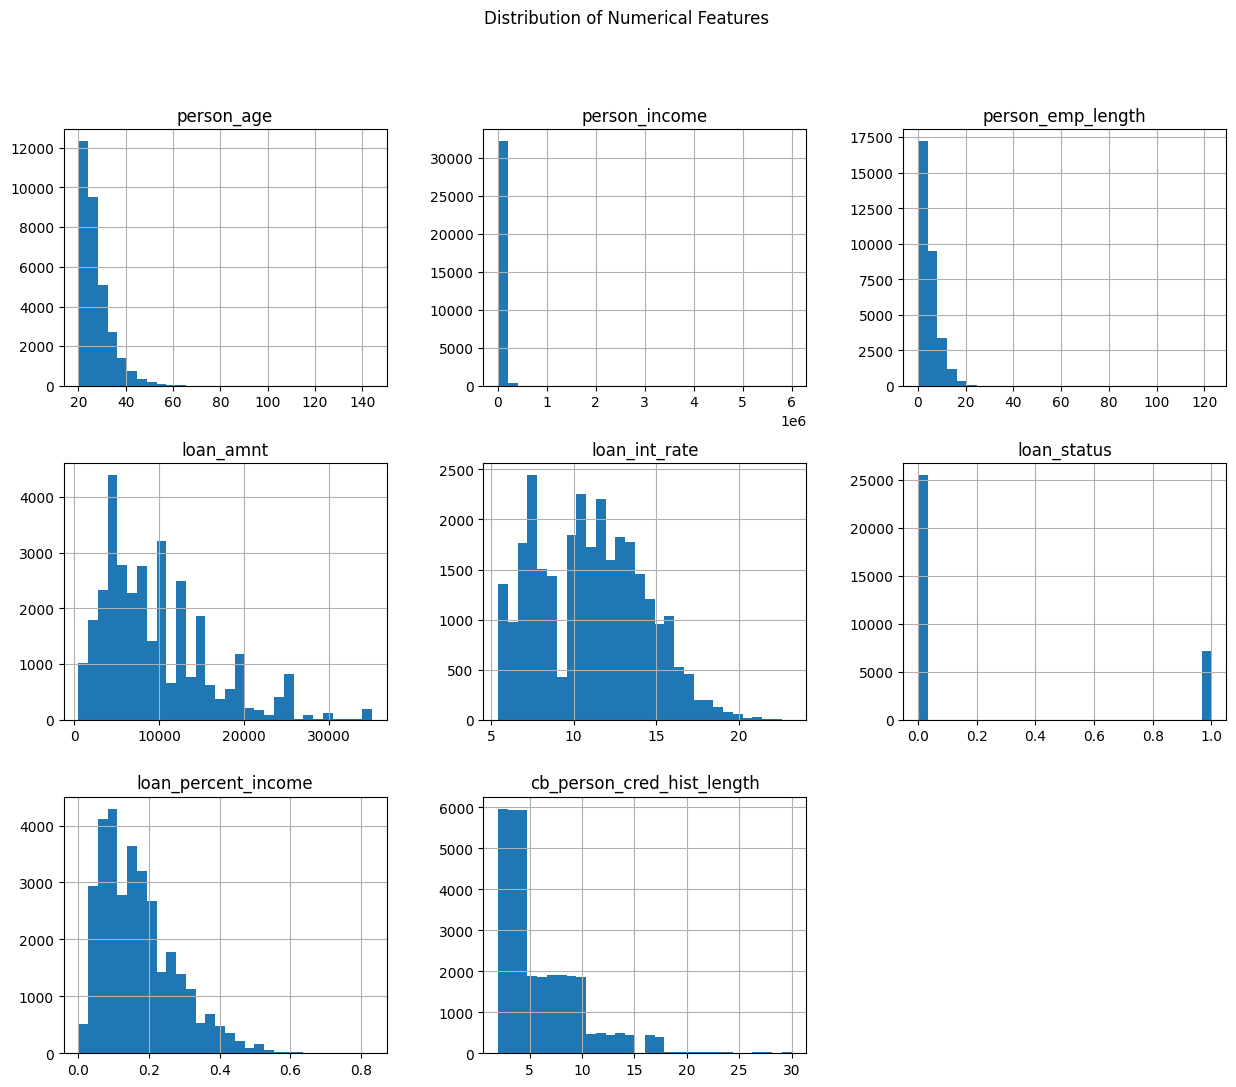

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(15, 12), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

** Categorical Feature Analysis**

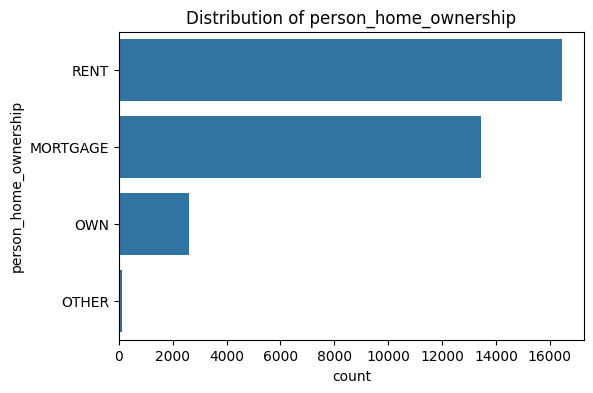

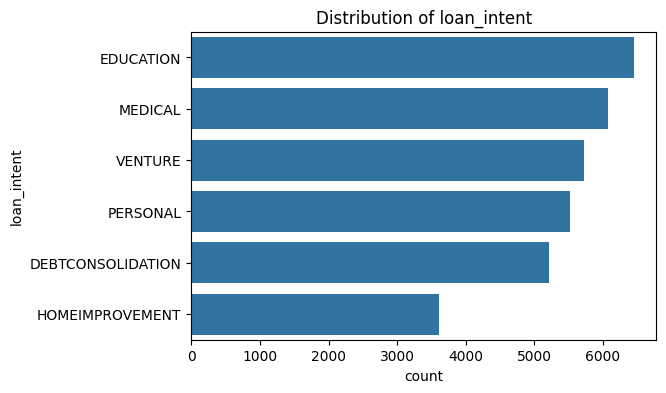

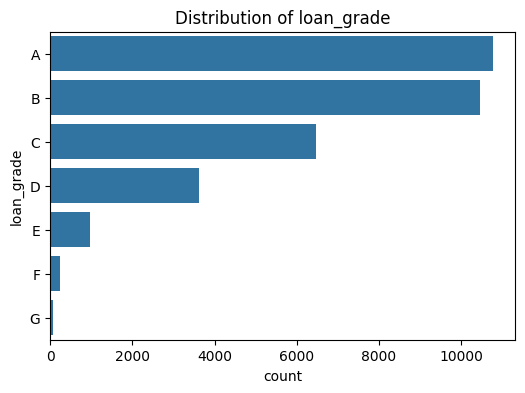

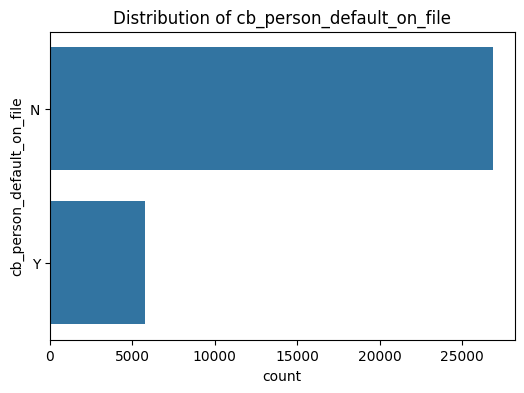

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

**Boxplots for Outlier Detection**

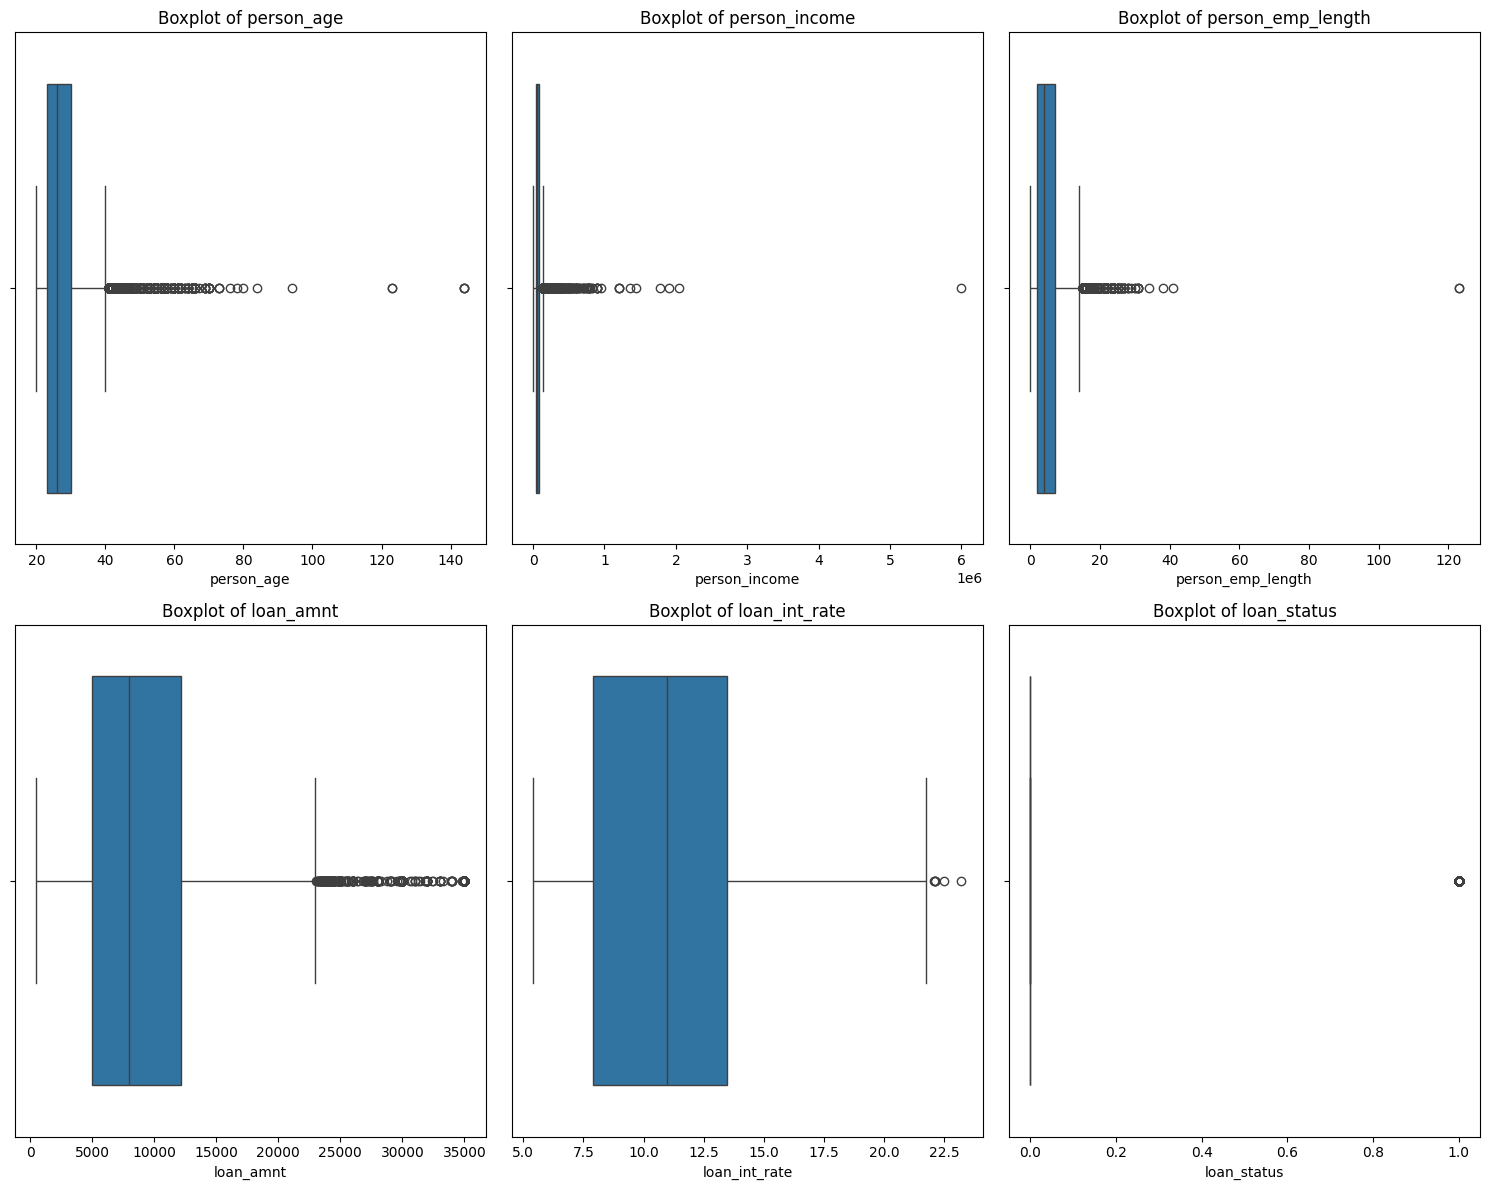

In [ ]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols[:6]):  # Show first 6 numerical features
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

**Remove Extreme Outliers That Are Unrealistic.**

In [ ]:
df_clean = df.copy()

# Basic sanity constraints (you can tweak if needed)
df_clean = df_clean[df_clean["person_age"] <= 90]
df_clean = df_clean[df_clean["person_age"] >= 18]
df_clean = df_clean[df_clean["person_emp_length"] <= 60]

TARGET = "loan_status"       # 0 = good, 1 = bad
y = df_clean[TARGET]
X = df_clean.drop(columns=[TARGET])

**Feature Engineering**

In [ ]:
df_fe = df_clean.copy()

# 1) Income to loan ratio
df_fe["income-loan_ratio"] = df_fe["person_income"] / (df_fe["loan_amnt"] + 1)

# 2) Interest burden (interest rate * percent income)
df_fe["interest_burden"] = df_fe["loan_int_rate"] * df_fe["loan_percent_income"]

# 3) Age x credit history length
df_fe["age_x_cred_hist"] = df_fe["person_age"] * df_fe["cb_person_cred_hist_length"]

# 4) Employment length missing flag
df_fe["emp_length_missing"] = df_fe["person_emp_length"].isna().astype(int)

# Update X, y
y = df_fe[TARGET]
X = df_fe.drop(columns=[TARGET])

**Train_Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Identify Numeric & Categorical Features**

In [ ]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_features, categorical_features

(['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length',
  'income-loan_ratio',
  'interest_burden',
  'age_x_cred_hist',
  'emp_length_missing'],
 ['person_home_ownership',
  'loan_intent',
  'loan_grade',
  'cb_person_default_on_file'])

**Preprocessing: Impute, PowerTransform, RobustScale, OneHot**

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Handle Class Imbalance: SMOTE, Class Weight**

In [ ]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
neg, pos, scale_pos_weight

(np.int64(19882), np.int64(5460), np.float64(3.6413919413919413))

**Define Model Pipeline with Hypermeter**

In [ ]:
lr = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="saga"  # supports L1 and L2
)

lr_param_dist = {
    "model__C": [0.01, 0.1, 1, 5, 10],
    "model__penalty": ["l2", "l1"]   # Ridge (l2) and Lasso (l1) – will pick best
}

lr_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", lr)
])

In [ ]:
svm = SVC(
    probability=True,
    class_weight="balanced"
)

svm_param_dist = {
    "model__C": [0.5, 1, 5, 10],
    "model__gamma": ["scale", 0.01, 0.001],
    "model__kernel": ["rbf"]
}

svm_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", svm)
])

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced_subsample"
)

rf_param_dist = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

rf_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", rf)
])

In [ ]:
lgbm = LGBMClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=300
)

lgbm_param_dist = {
    "model__num_leaves": [31, 63, 127],
    "model__max_depth": [-1, 6, 10],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.9, 1.0]
}

lgbm_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", lgbm)
])

In [ ]:
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

xgb_param_dist = {
    "model__n_estimators": [300, 500, 800],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 6, 8],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.9, 1.0],
    "model__gamma": [0, 1, 5],
    "model__reg_lambda": [0.0, 1.0, 5.0]  # L2 regularization (Ridge-like)
}

xgb_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", xgb)
])

**Hypermeter Tuning Class**

In [ ]:
def tune_model(name, pipeline, param_dist, X_train, y_train, cv_splits=3, n_iter=20):
    print(f"\n===== Tuning {name} =====")
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    search.fit(X_train, y_train)

    print("Best CV accuracy:", search.best_score_)
    print("Best params:", search.best_params_)

    return search.best_estimator_, search.best_score_

**Tune Models**

In [ ]:
best_models = {}
cv_scores = {}

best_lr,  cv_lr  = tune_model("Logistic Regression", lr_pipeline,  lr_param_dist,  X_train, y_train)
best_svm, cv_svm = tune_model("SVM",                svm_pipeline, svm_param_dist, X_train, y_train)
best_rf,  cv_rf  = tune_model("Random Forest",      rf_pipeline,  rf_param_dist,  X_train, y_train)
best_lgbm,cv_lgbm= tune_model("LightGBM",          lgbm_pipeline,lgbm_param_dist,X_train, y_train)
best_xgb, cv_xgb = tune_model("XGBoost",           xgb_pipeline, xgb_param_dist, X_train, y_train)

best_models["Logistic Regression"] = best_lr
best_models["SVM"] = best_svm
best_models["Random Forest"] = best_rf
best_models["LightGBM"] = best_lgbm
best_models["XGBoost"] = best_xgb

cv_scores = {
    "Logistic Regression": cv_lr,
    "SVM": cv_svm,
    "Random Forest": cv_rf,
    "LightGBM": cv_lgbm,
    "XGBoost": cv_xgb
}

print("\n=== CV Scores (mean accuracy) ===")
for k, v in cv_scores.items():
    print(f"{k}: {v:.4f}")


===== Tuning Logistic Regression =====
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV accuracy: 0.8015549860135031
Best params: {'model__penalty': 'l1', 'model__C': 10}

===== Tuning SVM =====
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best CV accuracy: 0.8959041617414227
Best params: {'model__kernel': 'rbf', 'model__gamma': 'scale', 'model__C': 10}

===== Tuning Random Forest =====
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV accuracy: 0.9286561275789146
Best params: {'model__n_estimators': 800, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 12}

===== Tuning LightGBM =====
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 19882, number of negative: 19882
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011133 seconds.
You can set `force_row_wise=true` to remove the overhe

**Evaluate Tuned Models with Test Set**


===== Logistic Regression (Test) =====
Test accuracy: 0.8025568181818182
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      4971
           1       0.53      0.79      0.63      1365

    accuracy                           0.80      6336
   macro avg       0.73      0.80      0.75      6336
weighted avg       0.85      0.80      0.81      6336



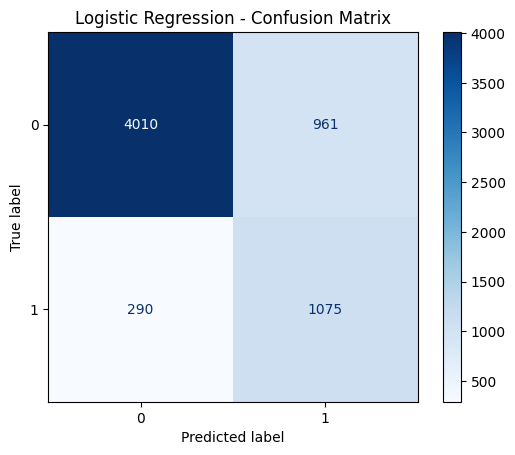


===== SVM (Test) =====
Test accuracy: 0.9037247474747475
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      4971
           1       0.79      0.75      0.77      1365

    accuracy                           0.90      6336
   macro avg       0.86      0.85      0.85      6336
weighted avg       0.90      0.90      0.90      6336



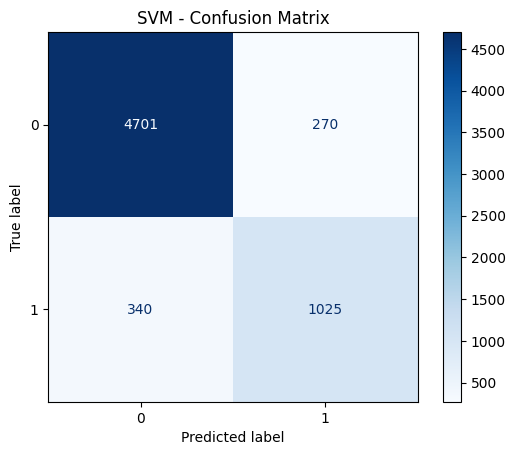


===== Random Forest (Test) =====
Test accuracy: 0.9316603535353535
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4971
           1       0.94      0.73      0.82      1365

    accuracy                           0.93      6336
   macro avg       0.93      0.86      0.89      6336
weighted avg       0.93      0.93      0.93      6336



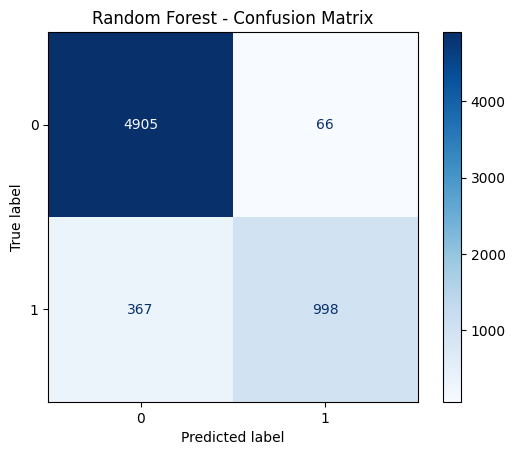


===== LightGBM (Test) =====
Test accuracy: 0.9381313131313131
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4971
           1       0.96      0.74      0.84      1365

    accuracy                           0.94      6336
   macro avg       0.95      0.87      0.90      6336
weighted avg       0.94      0.94      0.94      6336



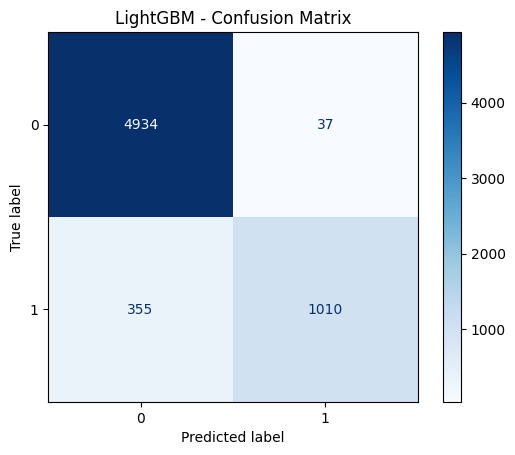


===== XGBoost (Test) =====
Test accuracy: 0.9332386363636364
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      4971
           1       0.90      0.78      0.83      1365

    accuracy                           0.93      6336
   macro avg       0.92      0.88      0.90      6336
weighted avg       0.93      0.93      0.93      6336



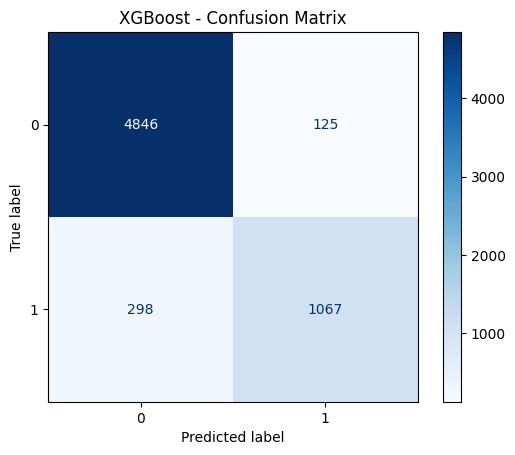

In [ ]:
test_results = {}

for name, model in best_models.items():
    print(f"\n===== {name} (Test) =====")
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    test_results[name] = acc

    print("Test accuracy:", acc)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

**Compare final test accuracie**

In [ ]:
print("\n=== Final Test Accuracies ===")
for k, v in test_results.items():
    print(f"{k}: {v:.4f}")


=== Final Test Accuracies ===
Logistic Regression: 0.8026
SVM: 0.9037
Random Forest: 0.9317
LightGBM: 0.9381
XGBoost: 0.9332
